# WGC Engine-Start Candidate Extraction

**Team Members:** Brooke Lumpkin and Aeon Levy  
**Project:** Sailplane Mid-Flight Engine-Start Analysis  
**Notebook Purpose:** Convert raw IGC flight logs into second-by-second flight data and identify possible engine-start events for later review.

## Project Objective

The goal of this notebook is to move from the flight-level data audit completed in Notebook 3 to a more detailed time-series analysis of individual flights.

This notebook focuses on three main tasks:

1. Parse the second-by-second B records from the sponsor-provided IGC files.
2. Extract available engine-related and flight-response measurements.
3. Identify preliminary engine-start candidates that can later be reviewed using the team’s decision tree.

The candidate events identified here are not yet labeled as successful, failed, false positive, or indeterminate. Final classification will require sponsor-confirmed examples, manual review, and validation of the decision rules.

## 1. Imports and Paths

In [2]:
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


RAW_DATA_DIR = Path("../data/wgc/wgc")
PROCESSED_DATA_DIR = Path("../data/processed")
FIGURE_DIR = Path("../reports/figures")

INVENTORY_PATH = PROCESSED_DATA_DIR / "wgc_flight_inventory.csv"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

igc_files = sorted(
    list(RAW_DATA_DIR.glob("*.igc"))
    + list(RAW_DATA_DIR.glob("*.IGC"))
)

print(f"Raw-data directory: {RAW_DATA_DIR.resolve()}")
print(f"IGC files discovered: {len(igc_files)}")
print(f"Inventory exists: {INVENTORY_PATH.exists()}")

Raw-data directory: /Users/brookelumpkin/Developer/UVA26_Sailplane-Capstone-clean/data/wgc/wgc
IGC files discovered: 992
Inventory exists: True


In [27]:
if len(igc_files) == 0:
    print(
        "\nWarning: No IGC files were found. "
        "Check RAW_DATA_DIR before continuing."
    )

if not INVENTORY_PATH.exists():
    print(
        "\nWarning: The Notebook 3 flight inventory was not found. "
        "Run Notebook 3 or copy the processed CSV into data/processed."
    )

## 2. Load the Flight-Level Inventory

Notebook 3 created one inventory row per IGC file. That inventory is used here to select files, confirm available variables, and connect candidate events to aircraft and recorder metadata.

In [3]:
flight_inventory = pd.read_csv(INVENTORY_PATH)

print(f"Inventory rows: {len(flight_inventory)}")
print(f"Files with parse errors: {flight_inventory['parse_error'].notna().sum()}")

flight_inventory.head()

Inventory rows: 992
Files with parse errors: 14


,file,date,glider_type,recorder_type,gps_receiver,pressure_sensor,motor_sensor,extensions,b_record_count,valid_b_record_count,...,RPM,TAS,GSP,VAT,NET,ACZ,AOR,AOP,OAT,extension_count
0,4536-9239003137.igc,"110824,1",JS-3-18m_2L,"LXNAV,LX9070PF","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m","LXV,ON,ACOUSTIC,MOP-(SN:10161,ET=582,41,582,41...","ACZ,AOA,AOP,AOR,ENL,FXA,GSP,MOP,NET,OAT,SIU,TA...",13618,13616,...,False,True,True,True,True,True,True,True,True,14
1,4536-9239003138.igc,"110824,1",18m AS33 @ventus,"LXNAV,LX9070PF","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m",NaN,"ACZ,AOA,AOP,AOR,ENL,FXA,GSP,NET,OAT,SIU,TAS,TR...",12240,12222,...,False,True,True,True,True,True,True,True,True,13
2,4536-9239003139.igc,"110824,1",JS-3-18m,"LXNAV,LX9070PF","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m",NaN,"ACZ,AOA,AOP,AOR,ENL,FXA,GSP,NET,OAT,SIU,TAS,TR...",14131,14131,...,False,True,True,True,True,True,True,True,True,13
3,4536-9239003142.igc,NaN,JS-3-18m,"LXNAV,LX9070PF","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m",NaN,"ACZ,ENL,FXA,GSP,OAT,TAS,TRT,VAT",16260,16260,...,False,True,True,True,False,True,False,False,True,8
4,4536-9239003143.igc,NaN,AS 33Es 18m,"LXNAV,LX9070","uBLOX NEO-M8Q,72,max50000m","INTERSEMA,MS5561C,max16000m",NaN,"ACZ,ENL,FXA,GSP,OAT,TAS,TRT,VAT",14112,14112,...,False,True,True,True,False,True,False,False,True,8


The inventory confirms that the detailed time-series analysis is being applied to the same collection of flights audited in Notebook 3.

## 3. Parse Optional IGC Variable Locations

IGC files can include additional variables such as ENL, MOP, RPM, TAS, GSP, and VAT. The character positions of these variables are defined separately within each file’s I record.

The function below reads the I record and stores the start and end positions for each available extension variable.

In [4]:
def parse_i_record_layout(line: str) -> dict[str, tuple[int, int]]:
    """
    Parse an IGC I record.

    Returns
    -------
    dict
        Mapping from extension code to a tuple containing its
        one-based inclusive start and end positions.
    """
    line = line.strip()

    if not line.startswith("I") or len(line) < 3:
        return {}

    try:
        extension_count = int(line[1:3])
    except ValueError:
        return {}

    layout: dict[str, tuple[int, int]] = {}

    for index in range(extension_count):
        group_start = 3 + index * 7
        group = line[group_start:group_start + 7]

        if len(group) != 7:
            continue

        try:
            start_position = int(group[0:2])
            end_position = int(group[2:4])
        except ValueError:
            continue

        code = group[4:7]

        if len(code) == 3 and code.isalnum():
            layout[code] = (start_position, end_position)

    return layout

### Helper Functions for Numeric Values and Time

The following helper functions safely convert text values into numeric values and convert IGC time fields into both readable UTC times and seconds after midnight.

In [5]:
def safe_int(value: str) -> float:
    """Convert a string to an integer-valued float or return NaN."""
    value = value.strip()

    if not value:
        return np.nan

    try:
        return float(int(value))
    except ValueError:
        return np.nan


def parse_igc_time(value: str) -> tuple[str, int]:
    """
    Parse HHMMSS into a display string and seconds after midnight.
    """
    if len(value) != 6 or not value.isdigit():
        return "", -1

    hour = int(value[0:2])
    minute = int(value[2:4])
    second = int(value[4:6])

    display_time = f"{hour:02d}:{minute:02d}:{second:02d}"
    seconds_after_midnight = hour * 3600 + minute * 60 + second

    return display_time, seconds_after_midnight

### Latitude and Longitude Conversion

IGC coordinates are stored using degrees, minutes, and thousandths of minutes. These functions convert the recorded coordinates into decimal degrees so that event locations can later be plotted and compared with terrain elevation.

In [6]:
def parse_latitude(value: str) -> float:
    """
    Parse IGC latitude DDMMmmmN/S into decimal degrees.
    """
    if len(value) != 8:
        return np.nan

    try:
        degrees = int(value[0:2])
        minutes = int(value[2:4])
        thousandths = int(value[4:7])
        hemisphere = value[7]

        decimal = degrees + (minutes + thousandths / 1000) / 60

        if hemisphere == "S":
            decimal *= -1

        return decimal

    except ValueError:
        return np.nan


def parse_longitude(value: str) -> float:
    """
    Parse IGC longitude DDDMMmmmE/W into decimal degrees.
    """
    if len(value) != 9:
        return np.nan

    try:
        degrees = int(value[0:3])
        minutes = int(value[3:5])
        thousandths = int(value[5:8])
        hemisphere = value[8]

        decimal = degrees + (minutes + thousandths / 1000) / 60

        if hemisphere == "W":
            decimal *= -1

        return decimal

    except ValueError:
        return np.nan

## 4. Parse Individual B Records

B records contain the second-by-second flight observations used in this analysis. Standard fields include time, location, validity, pressure altitude, and GNSS altitude.

When optional variables are available, their values are extracted using the file-specific layout defined in the I record.

In [7]:
def parse_b_record(
    line: str,
    extension_layout: dict[str, tuple[int, int]],
) -> dict[str, Any] | None:
    """
    Parse one IGC B record into a dictionary.
    """
    line = line.rstrip("\n\r")

    if not line.startswith("B") or len(line) < 35:
        return None

    time_text, seconds_after_midnight = parse_igc_time(line[1:7])

    record: dict[str, Any] = {
        "time_utc": time_text,
        "seconds_after_midnight": seconds_after_midnight,
        "latitude": parse_latitude(line[7:15]),
        "longitude": parse_longitude(line[15:24]),
        "validity": line[24],
        "pressure_altitude_m": safe_int(line[25:30]),
        "gnss_altitude_m": safe_int(line[30:35]),
    }

    for code, (start_position, end_position) in extension_layout.items():
        # IGC positions are one-based and inclusive.
        raw_value = line[start_position - 1:end_position]
        record[code] = safe_int(raw_value)

    return record

## 5. Convert One Complete IGC File into a Time-Series Table

The next function reads one complete flight log and converts all B records into a pandas DataFrame. It also adjusts the time sequence for flights that continue past midnight.

In [8]:
def parse_igc_timeseries(file_path: Path) -> pd.DataFrame:
    """
    Parse one IGC file into a time-series DataFrame.
    """
    extension_layout: dict[str, tuple[int, int]] = {}
    records: list[dict[str, Any]] = []

    with file_path.open(
        "r",
        encoding="latin-1",
        errors="replace",
    ) as file:

        for raw_line in file:
            line = raw_line.strip()

            if line.startswith("I"):
                extension_layout.update(parse_i_record_layout(line))

            elif line.startswith("B"):
                parsed_record = parse_b_record(
                    line,
                    extension_layout,
                )

                if parsed_record is not None:
                    records.append(parsed_record)

    flight_df = pd.DataFrame(records)

    if flight_df.empty:
        return flight_df

    flight_df["file"] = file_path.name

    # Handle flights that cross midnight.
    raw_seconds = flight_df["seconds_after_midnight"].to_numpy(dtype=float)
    adjusted_seconds = raw_seconds.copy()

    day_offset = 0

    for index in range(1, len(adjusted_seconds)):
        if raw_seconds[index] < raw_seconds[index - 1] - 43200:
            day_offset += 86400

        adjusted_seconds[index] += day_offset

    flight_df["adjusted_seconds"] = adjusted_seconds
    flight_df["elapsed_seconds"] = (
        flight_df["adjusted_seconds"]
        - flight_df["adjusted_seconds"].iloc[0]
    )

    return flight_df

## 6. Test the Parser on One Example Flight

Before applying the parser to multiple files, it is tested on one flight. This allows the team to confirm that the time, location, altitude, and optional variables are being extracted correctly.

In [9]:
sample_file = igc_files[0]

sample_flight = parse_igc_timeseries(sample_file)

print(f"Sample file: {sample_file.name}")
print(f"Time-series rows: {len(sample_flight)}")
print(f"Columns parsed: {sample_flight.columns.tolist()}")

sample_flight.head()

Sample file: 4536-9239003137.igc
Time-series rows: 13618
Columns parsed: ['time_utc', 'seconds_after_midnight', 'latitude', 'longitude', 'validity', 'pressure_altitude_m', 'gnss_altitude_m', 'FXA', 'SIU', 'ENL', 'TAS', 'GSP', 'TRT', 'VAT', 'OAT', 'NET', 'MOP', 'ACZ', 'AOR', 'AOP', 'AOA', 'file', 'adjusted_seconds', 'elapsed_seconds']


,time_utc,seconds_after_midnight,latitude,longitude,validity,pressure_altitude_m,gnss_altitude_m,FXA,SIU,ENL,...,OAT,NET,MOP,ACZ,AOR,AOP,AOA,file,adjusted_seconds,elapsed_seconds
0,18:26:59,66419,29.216167,-99.746183,A,261.0,267.0,7.0,8.0,4.0,...,379.0,0.0,1.0,80.0,1.0,35.0,0.0,4536-9239003137.igc,66419.0,0.0
1,18:27:00,66420,29.216167,-99.746183,A,262.0,267.0,7.0,8.0,4.0,...,378.0,0.0,1.0,80.0,1.0,35.0,0.0,4536-9239003137.igc,66420.0,1.0
2,18:27:01,66421,29.216167,-99.746183,A,261.0,267.0,7.0,8.0,4.0,...,378.0,0.0,1.0,80.0,1.0,35.0,0.0,4536-9239003137.igc,66421.0,2.0
3,18:27:02,66422,29.216167,-99.746183,A,262.0,267.0,7.0,8.0,4.0,...,378.0,0.0,1.0,80.0,1.0,35.0,0.0,4536-9239003137.igc,66422.0,3.0
4,18:27:03,66423,29.216167,-99.746183,A,262.0,267.0,7.0,8.0,4.0,...,378.0,0.0,1.0,80.0,1.0,35.0,0.0,4536-9239003137.igc,66423.0,4.0


In [30]:
if not igc_files:
    raise FileNotFoundError(
        "No IGC files were found. Check RAW_DATA_DIR before continuing."
    )

sample_file = igc_files[0]

sample_flight = parse_igc_timeseries(sample_file)

print(f"Sample file: {sample_file.name}")
print(f"Time-series rows: {len(sample_flight)}")
print(f"Columns parsed: {sample_flight.columns.tolist()}")

sample_flight.head()

Sample file: 4536-9239003137.igc
Time-series rows: 13618
Columns parsed: ['time_utc', 'seconds_after_midnight', 'latitude', 'longitude', 'validity', 'pressure_altitude_m', 'gnss_altitude_m', 'FXA', 'SIU', 'ENL', 'TAS', 'GSP', 'TRT', 'VAT', 'OAT', 'NET', 'MOP', 'ACZ', 'AOR', 'AOP', 'AOA', 'file', 'adjusted_seconds', 'elapsed_seconds']


,time_utc,seconds_after_midnight,latitude,longitude,validity,pressure_altitude_m,gnss_altitude_m,FXA,SIU,ENL,...,OAT,NET,MOP,ACZ,AOR,AOP,AOA,file,adjusted_seconds,elapsed_seconds
0,18:26:59,66419,29.216167,-99.746183,A,261.0,267.0,7.0,8.0,4.0,...,379.0,0.0,1.0,80.0,1.0,35.0,0.0,4536-9239003137.igc,66419.0,0.0
1,18:27:00,66420,29.216167,-99.746183,A,262.0,267.0,7.0,8.0,4.0,...,378.0,0.0,1.0,80.0,1.0,35.0,0.0,4536-9239003137.igc,66420.0,1.0
2,18:27:01,66421,29.216167,-99.746183,A,261.0,267.0,7.0,8.0,4.0,...,378.0,0.0,1.0,80.0,1.0,35.0,0.0,4536-9239003137.igc,66421.0,2.0
3,18:27:02,66422,29.216167,-99.746183,A,262.0,267.0,7.0,8.0,4.0,...,378.0,0.0,1.0,80.0,1.0,35.0,0.0,4536-9239003137.igc,66422.0,3.0
4,18:27:03,66423,29.216167,-99.746183,A,262.0,267.0,7.0,8.0,4.0,...,378.0,0.0,1.0,80.0,1.0,35.0,0.0,4536-9239003137.igc,66423.0,4.0


### Sample Flight Data-Quality Check

This table checks whether the sample flight contains valid B records and whether important fields such as latitude, longitude, and altitude are missing.

In [10]:
sample_validation = pd.DataFrame({
    "Measure": [
        "Time-series rows",
        "Valid B records",
        "Invalid B records",
        "Missing pressure altitude",
        "Missing GNSS altitude",
        "Missing latitude",
        "Missing longitude",
    ],
    "Count": [
        len(sample_flight),
        int((sample_flight["validity"] == "A").sum()),
        int((sample_flight["validity"] == "V").sum()),
        int(sample_flight["pressure_altitude_m"].isna().sum()),
        int(sample_flight["gnss_altitude_m"].isna().sum()),
        int(sample_flight["latitude"].isna().sum()),
        int(sample_flight["longitude"].isna().sum()),
    ],
})

sample_validation

,Measure,Count
0,Time-series rows,13618
1,Valid B records,13616
2,Invalid B records,2
3,Missing pressure altitude,0
4,Missing GNSS altitude,0
5,Missing latitude,0
6,Missing longitude,0


The parser should not be applied to the full dataset until the missing-value counts and record-validity counts appear reasonable.

## 7. Create Derived Flight-Response Variables

The sponsor is interested in what happens to the aircraft after a possible engine-start attempt. To support that analysis, this section creates:

- a common altitude field;
- estimated vertical speed;
- a smoothed vertical-speed measure.

GNSS altitude is used when available, with pressure altitude used as a fallback.

In [11]:
def add_derived_flight_variables(
    flight_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Add common altitude and vertical-response variables.
    """
    result = flight_df.copy()

    result["analysis_altitude_m"] = (
        result["gnss_altitude_m"]
        .where(
            result["gnss_altitude_m"].notna(),
            result["pressure_altitude_m"],
        )
    )

    time_difference = result["adjusted_seconds"].diff()
    altitude_difference = result["analysis_altitude_m"].diff()

    result["derived_vertical_speed_mps"] = (
        altitude_difference / time_difference
    )

    invalid_time_step = (
        time_difference.isna()
        | (time_difference <= 0)
        | (time_difference > 30)
    )

    result.loc[
        invalid_time_step,
        "derived_vertical_speed_mps",
    ] = np.nan

    result["vertical_speed_smoothed_mps"] = (
        result["derived_vertical_speed_mps"]
        .rolling(
            window=15,
            center=True,
            min_periods=5,
        )
        .median()
    )

    return result

In [12]:
sample_flight = add_derived_flight_variables(sample_flight)

sample_flight[
    [
        "time_utc",
        "analysis_altitude_m",
        "derived_vertical_speed_mps",
        "vertical_speed_smoothed_mps",
    ]
].head(20)

,time_utc,analysis_altitude_m,derived_vertical_speed_mps,vertical_speed_smoothed_mps
0,18:26:59,267.0,NaN,0.0
1,18:27:00,267.0,0.0,0.0
2,18:27:01,267.0,0.0,0.0
3,18:27:02,267.0,0.0,0.0
4,18:27:03,267.0,0.0,0.0
5,18:27:05,267.0,0.0,0.0
6,18:27:06,267.0,0.0,0.0
7,18:27:07,267.0,0.0,0.0
8,18:27:08,267.0,0.0,0.0
9,18:27:09,267.0,0.0,0.0


## 8. Review the Example Flight Trace

The following plots are used to visually confirm that the parsed altitude and derived vertical-speed measurements behave reasonably over the course of the sample flight.

These figures are parser checks and should not yet be interpreted as evidence of an engine-start event.

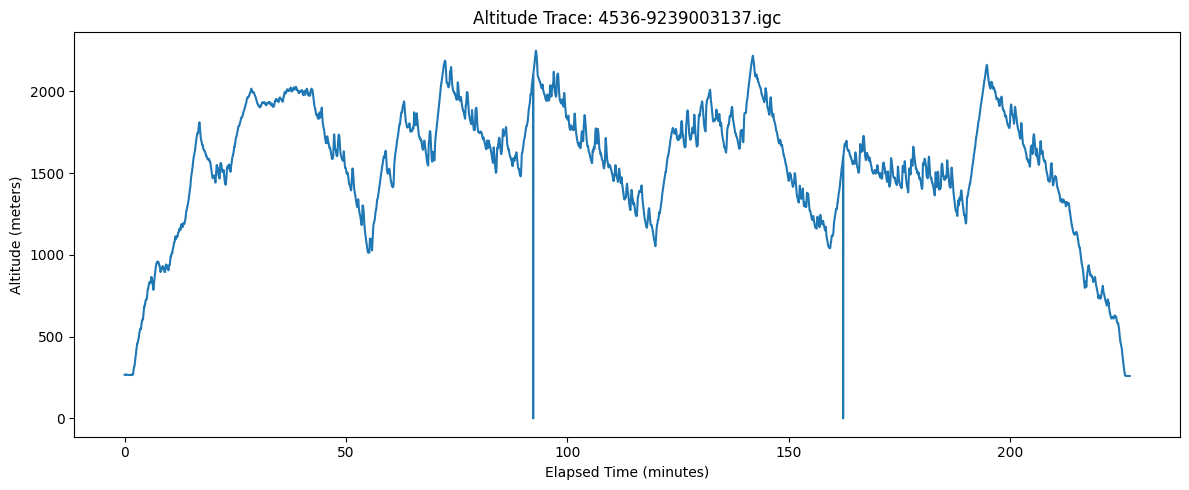

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    sample_flight["elapsed_seconds"] / 60,
    sample_flight["analysis_altitude_m"],
)

plt.title(f"Altitude Trace: {sample_file.name}")
plt.xlabel("Elapsed Time (minutes)")
plt.ylabel("Altitude (meters)")
plt.tight_layout()
plt.show()

The altitude trace provides a basic check that the parsed flight sequence is continuous and physically reasonable.

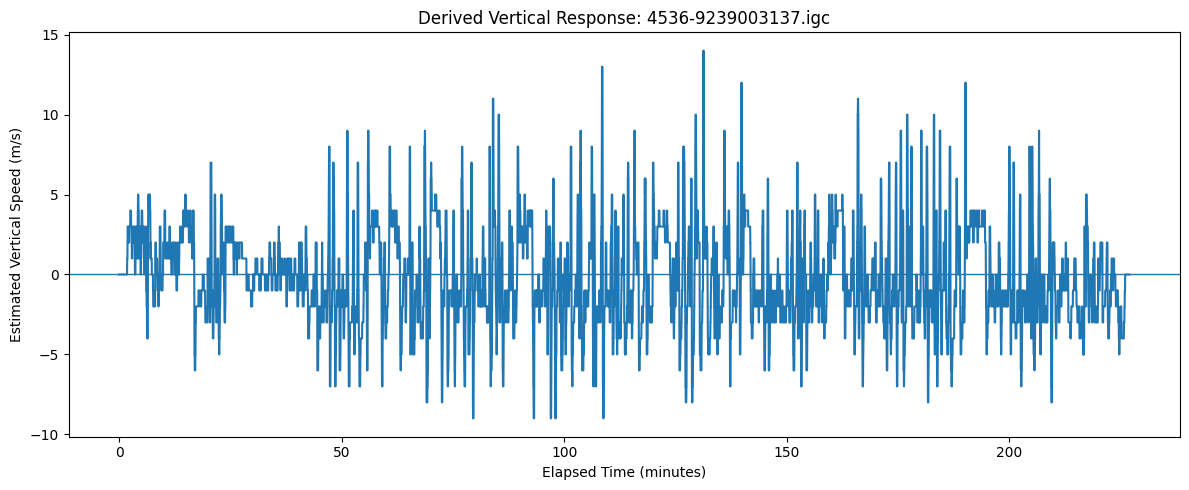

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    sample_flight["elapsed_seconds"] / 60,
    sample_flight["vertical_speed_smoothed_mps"],
)

plt.axhline(0, linewidth=1)

plt.title(f"Derived Vertical Response: {.name}")
plt.xlabel("Elapsed Time (minutes)")
plt.ylabel("Estimated Vertical Speed (m/s)")
plt.tight_layout()
plt.show()

The smoothed vertical-speed trace will later help describe whether the aircraft’s climb or descent behavior changes after a possible engine event.

## 9. Identify Preliminary Motor-Signal Activity

A possible engine-start event may be associated with changes in ENL, MOP, or RPM. Because the signal ranges can differ across aircraft and recorder systems, this notebook uses changes relative to each flight’s own recent baseline.

The activity flags created in this section are only used to generate possible candidates. They do not confirm that the engine started successfully.

In [15]:
MOTOR_SIGNAL_COLUMNS = ["ENL", "MOP", "RPM"]


def robust_activity_flag(
    series: pd.Series,
    baseline_window: int = 120,
    z_threshold: float = 6.0,
) -> pd.Series:
    """
    Identify unusually elevated values relative to a rolling baseline.

    This is intended for candidate generation, not final classification.
    """
    numeric = pd.to_numeric(series, errors="coerce")

    rolling_median = numeric.rolling(
        window=baseline_window,
        min_periods=max(20, baseline_window // 4),
    ).median()

    absolute_deviation = (numeric - rolling_median).abs()

    rolling_mad = absolute_deviation.rolling(
        window=baseline_window,
        min_periods=max(20, baseline_window // 4),
    ).median()

    robust_scale = 1.4826 * rolling_mad
    robust_scale = robust_scale.replace(0, np.nan)

    robust_z = (numeric - rolling_median) / robust_scale

    return (robust_z >= z_threshold).fillna(False)

In [16]:
def add_motor_activity_flags(
    flight_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Add preliminary activity flags for available motor-related variables.
    """
    result = flight_df.copy()

    activity_columns = []

    for signal in MOTOR_SIGNAL_COLUMNS:
        if signal not in result.columns:
            continue

        flag_column = f"{signal}_activity"

        result[flag_column] = robust_activity_flag(
            result[signal],
        )

        activity_columns.append(flag_column)

    if activity_columns:
        result["motor_evidence_count"] = (
            result[activity_columns].sum(axis=1)
        )

        result["candidate_motor_activity"] = (
            result["motor_evidence_count"] >= 1
        )

    else:
        result["motor_evidence_count"] = 0
        result["candidate_motor_activity"] = False

    # Exclude the first five minutes as a preliminary method
    # for reducing initial-launch and test-event contamination.
    result.loc[
        result["elapsed_seconds"] < 300,
        "candidate_motor_activity",
    ] = False

    return result

In [17]:
sample_flight = add_motor_activity_flags(sample_flight)

activity_columns = [
    column
    for column in sample_flight.columns
    if column.endswith("_activity")
]

print("Available activity flags:", activity_columns)
print(
    "Candidate activity points:",
    int(sample_flight["candidate_motor_activity"].sum()),
)

Available activity flags: ['ENL_activity', 'MOP_activity', 'candidate_motor_activity']
Candidate activity points: 12


## 10. Group Activity Points into Candidate Events

A single engine-start attempt may create several elevated observations over a short period. This section groups nearby activity points into one candidate event so that the results can be reviewed at the event level rather than one second at a time.

In [18]:
def group_candidate_events(
    flight_df: pd.DataFrame,
    maximum_gap_seconds: int = 15,
) -> pd.DataFrame:
    """
    Group candidate motor-activity rows into candidate event intervals.
    """
    candidate_rows = flight_df.loc[
        flight_df["candidate_motor_activity"]
    ].copy()

    if candidate_rows.empty:
        return pd.DataFrame()

    time_gaps = candidate_rows["adjusted_seconds"].diff()

    candidate_rows["event_group"] = (
        (time_gaps.isna())
        | (time_gaps > maximum_gap_seconds)
    ).cumsum()

    events = []

    for event_group, event_rows in candidate_rows.groupby("event_group"):
        event_start_seconds = event_rows["adjusted_seconds"].iloc[0]
        event_end_seconds = event_rows["adjusted_seconds"].iloc[-1]

        events.append({
            "file": event_rows["file"].iloc[0],
            "event_group": int(event_group),
            "event_start_time_utc": event_rows["time_utc"].iloc[0],
            "event_end_time_utc": event_rows["time_utc"].iloc[-1],
            "event_start_seconds": event_start_seconds,
            "event_end_seconds": event_end_seconds,
            "event_duration_seconds": (
                event_end_seconds
                - event_start_seconds
                + 1
            ),
            "ENL_evidence": bool(
                event_rows.get(
                    "ENL_activity",
                    pd.Series(False, index=event_rows.index),
                ).any()
            ),
            "MOP_evidence": bool(
                event_rows.get(
                    "MOP_activity",
                    pd.Series(False, index=event_rows.index),
                ).any()
            ),
            "RPM_evidence": bool(
                event_rows.get(
                    "RPM_activity",
                    pd.Series(False, index=event_rows.index),
                ).any()
            ),
            "maximum_motor_evidence_count": int(
                event_rows["motor_evidence_count"].max()
            ),
        })

    return pd.DataFrame(events)

In [19]:
sample_events = group_candidate_events(sample_flight)

print(f"Candidate events in sample file: {len(sample_events)}")
sample_events.head(20)

Candidate events in sample file: 1


,file,event_group,event_start_time_utc,event_end_time_utc,event_start_seconds,event_end_seconds,event_duration_seconds,ENL_evidence,MOP_evidence,RPM_evidence,maximum_motor_evidence_count
0,4536-9239003137.igc,1,18:33:58,18:34:09,66838.0,66849.0,12.0,False,True,False,1


At this stage, the event table only records when possible motor-related activity occurred and which signals contributed to the candidate.

## 11. Summarize Flight Behavior Before and After Each Candidate

For each possible event, this section calculates descriptive features from the periods before, during, and after the candidate.

These features include:

- altitude at the candidate start
- latitude and longitude
- average vertical speed before the candidate
- average vertical speed after the candidate
- altitude change after the candidate
- maximum ENL, MOP, and RPM values
- median signal values before and after the event

These features will later be used with the team’s decision tree to distinguish successful starts, failed attempts, false positives, and uncertain events.

In [20]:
def summarize_candidate_event(
    flight_df: pd.DataFrame,
    event_row: pd.Series,
    pre_window_seconds: int = 60,
    post_window_seconds: int = 120,
) -> dict[str, Any]:
    """
    Create event-level features for one candidate event.
    """
    event_start = float(event_row["event_start_seconds"])
    event_end = float(event_row["event_end_seconds"])

    pre_window = flight_df.loc[
        (flight_df["adjusted_seconds"] >= event_start - pre_window_seconds)
        & (flight_df["adjusted_seconds"] < event_start)
    ]

    event_window = flight_df.loc[
        (flight_df["adjusted_seconds"] >= event_start)
        & (flight_df["adjusted_seconds"] <= event_end)
    ]

    post_window = flight_df.loc[
        (flight_df["adjusted_seconds"] > event_end)
        & (
            flight_df["adjusted_seconds"]
            <= event_end + post_window_seconds
        )
    ]

    start_row = event_window.iloc[0]

    altitude_at_start = start_row.get(
        "analysis_altitude_m",
        np.nan,
    )

    post_final_altitude = (
        post_window["analysis_altitude_m"].dropna().iloc[-1]
        if not post_window["analysis_altitude_m"].dropna().empty
        else np.nan
    )

    altitude_change_post = (
        post_final_altitude - altitude_at_start
        if pd.notna(altitude_at_start)
        and pd.notna(post_final_altitude)
        else np.nan
    )

    summary: dict[str, Any] = {
        **event_row.to_dict(),
        "start_latitude": start_row.get("latitude", np.nan),
        "start_longitude": start_row.get("longitude", np.nan),
        "pressure_altitude_at_start_m": start_row.get(
            "pressure_altitude_m",
            np.nan,
        ),
        "gnss_altitude_at_start_m": start_row.get(
            "gnss_altitude_m",
            np.nan,
        ),
        "analysis_altitude_at_start_m": altitude_at_start,
        "pre_vertical_speed_mean_mps": (
            pre_window["vertical_speed_smoothed_mps"].mean()
        ),
        "post_vertical_speed_mean_mps": (
            post_window["vertical_speed_smoothed_mps"].mean()
        ),
        "post_altitude_change_m": altitude_change_post,
        "pre_window_rows": len(pre_window),
        "post_window_rows": len(post_window),
    }

    for signal in MOTOR_SIGNAL_COLUMNS:
        if signal in flight_df.columns:
            summary[f"{signal}_event_max"] = event_window[signal].max()
            summary[f"{signal}_pre_median"] = pre_window[signal].median()
            summary[f"{signal}_post_median"] = post_window[signal].median()
        else:
            summary[f"{signal}_event_max"] = np.nan
            summary[f"{signal}_pre_median"] = np.nan
            summary[f"{signal}_post_median"] = np.nan

    return summary

In [21]:
sample_event_features = pd.DataFrame(
    [
        summarize_candidate_event(
            sample_flight,
            event_row,
        )
        for _, event_row in sample_events.iterrows()
    ]
)

sample_event_features.head()

,file,event_group,event_start_time_utc,event_end_time_utc,event_start_seconds,event_end_seconds,event_duration_seconds,ENL_evidence,MOP_evidence,RPM_evidence,...,post_window_rows,ENL_event_max,ENL_pre_median,ENL_post_median,MOP_event_max,MOP_pre_median,MOP_post_median,RPM_event_max,RPM_pre_median,RPM_post_median
0,4536-9239003137.igc,1,18:33:58,18:34:09,66838.0,66849.0,12.0,False,True,False,...,120,4.0,4.0,4.0,431.0,13.0,1.0,NaN,NaN,NaN


## 12. Visualize a Candidate Event

Candidate-event plots allow the team to visually review the evidence surrounding a possible engine start.

The event start and end are marked on the plots so that changes in altitude and motor-related measurements can be compared within the same time window.

In [22]:
def plot_candidate_event(
    flight_df: pd.DataFrame,
    event_row: pd.Series,
    window_seconds: int = 180,
) -> None:
    """
    Plot altitude and available motor signals around one candidate.
    """
    event_start = float(event_row["event_start_seconds"])
    event_end = float(event_row["event_end_seconds"])

    plot_window = flight_df.loc[
        (
            flight_df["adjusted_seconds"]
            >= event_start - window_seconds
        )
        & (
            flight_df["adjusted_seconds"]
            <= event_end + window_seconds
        )
    ].copy()

    relative_time = (
        plot_window["adjusted_seconds"] - event_start
    )

    plt.figure(figsize=(12, 5))
    plt.plot(
        relative_time,
        plot_window["analysis_altitude_m"],
    )
    plt.axvline(0, linestyle="--")
    plt.axvline(
        event_end - event_start,
        linestyle="--",
    )
    plt.title(
        f"Altitude Around Candidate Event: "
        f"{event_row['file']}"
    )
    plt.xlabel("Seconds Relative to Candidate Start")
    plt.ylabel("Altitude (meters)")
    plt.tight_layout()
    plt.show()

    available_signals = [
        signal
        for signal in MOTOR_SIGNAL_COLUMNS
        if signal in plot_window.columns
    ]

    if available_signals:
        plt.figure(figsize=(12, 5))

        for signal in available_signals:
            plt.plot(
                relative_time,
                plot_window[signal],
                label=signal,
            )

        plt.axvline(0, linestyle="--")
        plt.axvline(
            event_end - event_start,
            linestyle="--",
        )
        plt.title(
            f"Motor Signals Around Candidate Event: "
            f"{event_row['file']}"
        )
        plt.xlabel("Seconds Relative to Candidate Start")
        plt.ylabel("Recorded Value")
        plt.legend()
        plt.tight_layout()
        plt.show()

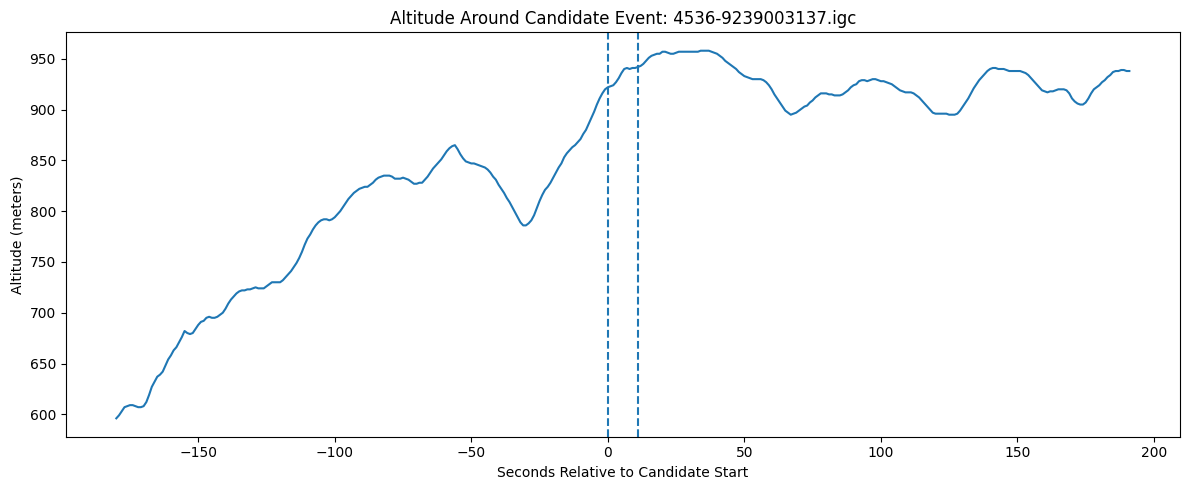

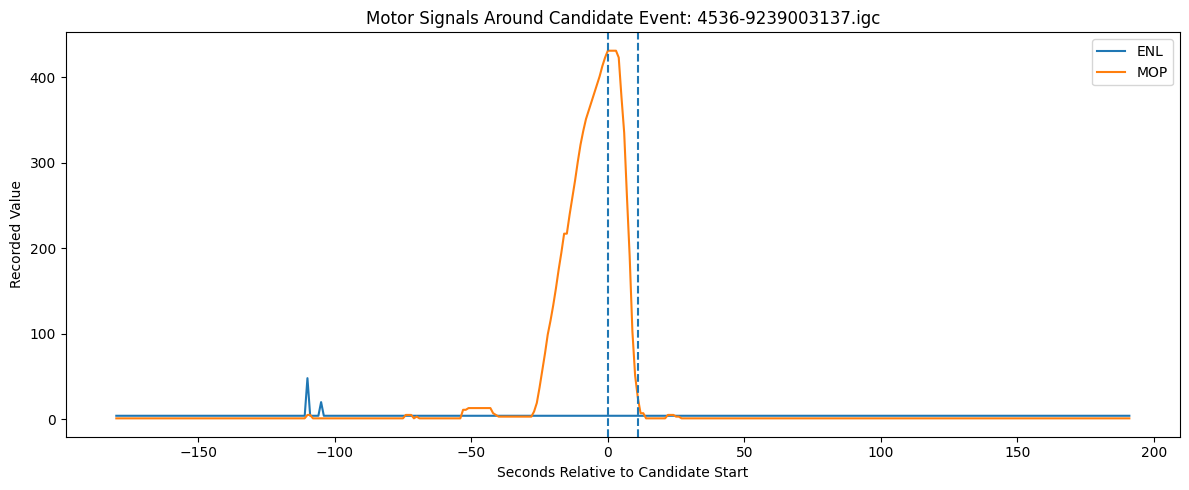

In [23]:
if not sample_events.empty:
    plot_candidate_event(
        sample_flight,
        sample_events.iloc[0],
    )
else:
    print("No candidate events were detected in the sample file.")

## 13. Pilot Batch Processing

Before processing the full archive, the candidate-extraction workflow is tested on a small set of files. This step checks runtime, parser consistency, and candidate counts before scaling.

In [24]:
PILOT_FILE_COUNT = 10

pilot_files = igc_files[:PILOT_FILE_COUNT]

pilot_candidate_tables = []
pilot_processing_log = []

for index, file_path in enumerate(pilot_files, start=1):
    try:
        flight_df = parse_igc_timeseries(file_path)

        if flight_df.empty:
            pilot_processing_log.append({
                "file": file_path.name,
                "status": "empty",
                "time_series_rows": 0,
                "candidate_events": 0,
            })
            continue

        flight_df = add_derived_flight_variables(flight_df)
        flight_df = add_motor_activity_flags(flight_df)

        events_df = group_candidate_events(flight_df)

        
            events_df.empty:
            event_features = pd.DataFrame(
                [
                    summarize_candidate_event(
                        flight_df,
                        event_row,
                    )
                    for _, event_row in events_df.iterrows()
                ]
            )

            pilot_candidate_tables.append(event_features)

        pilot_processing_log.append({
            "file": file_path.name,
            "status": "processed",
            "time_series_rows": len(flight_df),
            "candidate_events": len(events_df),
        })

        print(
            f"Processed {index}/{len(pilot_files)}: "
            f"{file_path.name} — {len(events_df)} candidates"
        )

    except Exception as error:
        pilot_processing_log.append({
            "file": file_path.name,
            "status": f"error: {error}",
            "time_series_rows": 0,
            "candidate_events": 0,
        })

pilot_log_df = pd.DataFrame(pilot_processing_log)

pilot_candidates_df = (
    pd.concat(
        pilot_candidate_tables,
        ignore_index=True,
    )
    if pilot_candidate_tables
    else pd.DataFrame()
)

pilot_log_df

Processed 1/10: 4536-9239003137.igc — 1 candidates
Processed 2/10: 4536-9239003138.igc — 2 candidates
Processed 3/10: 4536-9239003139.igc — 0 candidates
Processed 4/10: 4536-9239003142.igc — 0 candidates
Processed 5/10: 4536-9239003143.igc — 1 candidates
Processed 6/10: 4536-9239003145.igc — 22 candidates
Processed 7/10: 4536-9239003146.igc — 6 candidates
Processed 8/10: 4536-9239003148.igc — 1 candidates
Processed 9/10: 4536-9239003150.igc — 6 candidates
Processed 10/10: 4536-9239003151.igc — 13 candidates


,file,status,time_series_rows,candidate_events
0,4536-9239003137.igc,processed,13618,1
1,4536-9239003138.igc,processed,12240,2
2,4536-9239003139.igc,processed,14131,0
3,4536-9239003142.igc,processed,16260,0
4,4536-9239003143.igc,processed,14112,1
5,4536-9239003145.igc,processed,14657,22
6,4536-9239003146.igc,processed,14655,6
7,4536-9239003148.igc,processed,6456,1
8,4536-9239003150.igc,processed,12952,6
9,4536-9239003151.igc,processed,11103,13


### Pilot Candidate Results

The processing log shows whether each pilot file was successfully parsed and how many candidate events were identified.

In [31]:
print(f"Pilot files requested: {PILOT_FILE_COUNT}")
print(f"Pilot files processed: {len(pilot_log_df)}")
print(f"Pilot candidate events: {len(pilot_candidates_df)}")

pilot_candidates_df.head()

Pilot files requested: 10
Pilot files processed: 10
Pilot candidate events: 52


,file,event_group,event_start_time_utc,event_end_time_utc,event_start_seconds,event_end_seconds,event_duration_seconds,ENL_evidence,MOP_evidence,RPM_evidence,...,post_window_rows,ENL_event_max,ENL_pre_median,ENL_post_median,MOP_event_max,MOP_pre_median,MOP_post_median,RPM_event_max,RPM_pre_median,RPM_post_median
0,4536-9239003137.igc,1,18:33:58,18:34:09,66838.0,66849.0,12.0,False,True,False,...,120,4.0,4.0,4.0,431.0,13.0,1.0,NaN,NaN,NaN
1,4536-9239003138.igc,1,21:42:40,21:42:40,78160.0,78160.0,1.0,True,False,False,...,120,62.0,999.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN
2,4536-9239003138.igc,2,21:43:34,21:43:34,78214.0,78214.0,1.0,True,False,False,...,121,222.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4536-9239003143.igc,1,19:01:25,19:01:25,68485.0,68485.0,1.0,True,False,False,...,120,818.0,846.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN
4,4536-9239003145.igc,1,18:56:06,18:56:17,68166.0,68177.0,12.0,True,False,False,...,119,999.0,976.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN


### Pilot Summary

In [32]:
processed_file_count = int(
    (pilot_log_df["status"] == "processed").sum()
)

error_file_count = int(
    pilot_log_df["status"]
    .astype(str)
    .str.startswith("error")
    .sum()
)

empty_file_count = int(
    (pilot_log_df["status"] == "empty").sum()
)

average_candidates = round(
    len(pilot_candidates_df) / max(processed_file_count, 1),
    2,
)

pilot_summary = pd.DataFrame({
    "Measure": [
        "Pilot files requested",
        "Files successfully processed",
        "Empty files",
        "Files with processing errors",
        "Total candidate events",
        "Average candidates per processed file",
    ],
    "Value": [
        PILOT_FILE_COUNT,
        processed_file_count,
        empty_file_count,
        error_file_count,
        len(pilot_candidates_df),
        average_candidates,
    ],
})

pilot_summary

,Measure,Value
0,Pilot files requested,10.0
1,Files successfully processed,10.0
2,Empty files,0.0
3,Files with processing errors,0.0
4,Total candidate events,52.0
5,Average candidates per processed file,5.2


The pilot results should be reviewed before processing the complete archive. Candidate counts that are unusually high may indicate that the preliminary activity threshold is too sensitive, while very low counts may indicate that real events are being missed.

## 13. Save Pilot Results

The pilot processing log, candidate-event table, and pilot summary are saved as CSV files so they can be reviewed by both team members and used in later decision-tree and validation work.

In [34]:
pilot_log_path = (
    PROCESSED_DATA_DIR
    / "wgc_candidate_extraction_pilot_log.csv"
)

pilot_candidates_path = (
    PROCESSED_DATA_DIR
    / "wgc_preliminary_candidates_pilot.csv"
)

pilot_summary_path = (
    PROCESSED_DATA_DIR
    / "wgc_candidate_extraction_pilot_summary.csv"
)

pilot_log_df.to_csv(
    pilot_log_path,
    index=False,
)

pilot_candidates_df.to_csv(
    pilot_candidates_path,
    index=False,
)

pilot_summary.to_csv(
    pilot_summary_path,
    index=False,
)

print("\nPilot outputs saved successfully.")
print(f"Pilot log: {pilot_log_path}")
print(f"Pilot candidates: {pilot_candidates_path}")
print(f"Pilot summary: {pilot_summary_path}")



Pilot outputs saved successfully.
Pilot log: ../data/processed/wgc_candidate_extraction_pilot_log.csv
Pilot candidates: ../data/processed/wgc_preliminary_candidates_pilot.csv
Pilot summary: ../data/processed/wgc_candidate_extraction_pilot_summary.csv
